In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import datetime

import torch

DATA_PATH = "E:/ML/UBC"
print(DATA_PATH)


E:/ML/UBC


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [3]:
trainList = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
trainList.head()

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


In [44]:
from sklearn.preprocessing import LabelEncoder

uniqueLabels = trainList["label"].unique()

enc = LabelEncoder()
enc.fit(uniqueLabels)
print(enc.classes_)
enc.transform(["LGSC"])

['CC' 'EC' 'HGSC' 'LGSC' 'MC']


array([3])

In [5]:
allFiles = []
stopLoop = False
for root, dirs, files in os.walk(DATA_PATH, "train_images_rescaled"):
    for f in files:
        if f.endswith(".png"):
            allFiles.append(os.path.join(root, f))
    
len(allFiles)

538

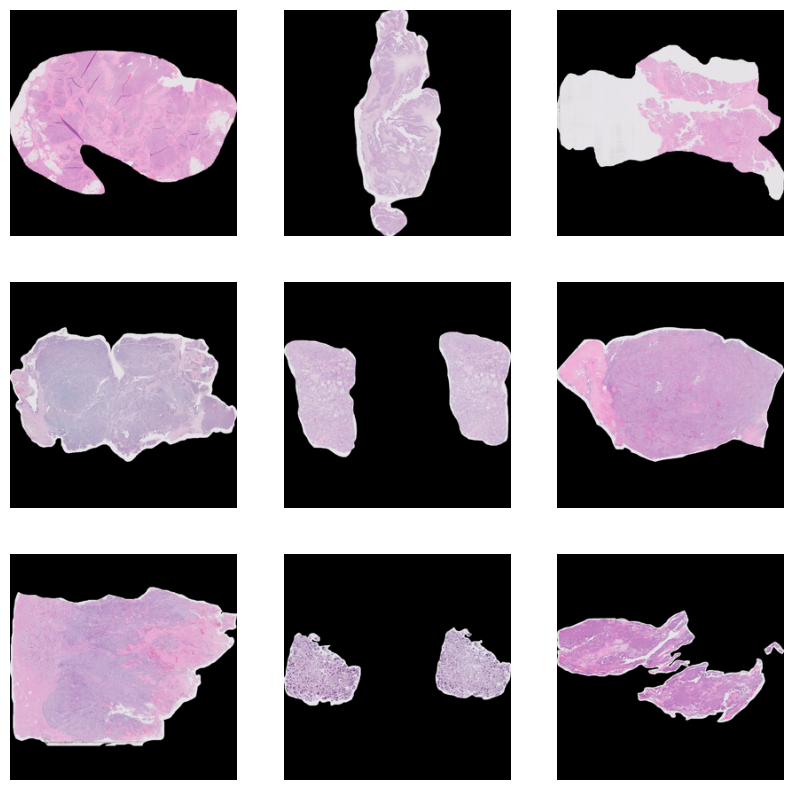

In [10]:

IMG_SIZE = (256, 256)
eps=1e-12

def readImage(path, skipResize=False):
    data = Image.open(path)
        
    w, h = data.width, data.height
    # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
    # medValue = np.median(data)

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    # data = data - np.min(data)
    # data = data * 1.0/(np.max(data)+eps)

    w, h = data.width, data.height

    # resize
    if not skipResize:
        if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
            data = np.array(data.resize(IMG_SIZE))
    
    # data = data/(np.max(data)+eps) * 2 - 1

    # data = (data * 255).astype(np.uint8)
    return data



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

In [14]:
allImages = {}
for i,filePath in enumerate(allFiles):
    im = readImage(filePath)
    id = filePath.split("\\")[-1].split(".")[0:-1][0]
    allImages[id] = im

10077
10143
1020
10246
10252
10469
10548
10642
1080
10800
10896
1101
11263
11417
11431
11557
11559
12159
12222
12244
12442
1252
12522
1289
12902
1295
13364
13387
13526
13568
13987
14039
14051
14127
14312
14401
14424
14532
14542
14617
15139
15188
15209
15221
15231
15293
15470
15486
15583
15671
15742
15871
15912
16042
16064
16209
16325
16494
1660
1666
16876
16986
17067
17174
17291
17365
17416
17487
17637
17738
1774
17854
18014
18138
18196
18547
18568
18607
18810
18813
18896
18914
18981
19030
19157
1925
19255
1943
19512
1952
19569
20205
20312
20316
20329
20463
20670
20858
20882
2097
21020
21232
21260
21303
21373
21432
21445
21910
21929
22155
22221
2227
22290
22425
22489
22654
22740
22924
23523
23629
23796
2391
24023
24507
24563
24617
24759
24991
25256
25331
25561
25604
25792
25923
25928
26025
26124
26190
26219
26533
26603
26644
2666
26862
26939
26950
2706
27245
27249
27315
27739
27747
27851
27950
28028
28066
281
28121
28393
28519
28562
286
28603
28736
28821
28922
2906
29084
29147
29200
29

In [87]:
TRAIN_TEST_SPLIT = 0.7

np.random.seed(56488)
# Make a deep copy such that the shuffling won't affect the patient id column in the dataset
# (skrews up the complete dataset)
trainListShuffle = trainList.copy(deep=True)
allIds = trainListShuffle["image_id"].to_numpy(copy=True)
split = int(allIds.shape[0]*TRAIN_TEST_SPLIT)
print("# Training samples:",split)
np.random.shuffle(allIds)
trainIds = allIds[0:split]
valIds = allIds[split::]

trainListIndexed= trainList.set_index("image_id")


def getData(id):
    arr = allImages[str(id)].astype(np.float32)/255.0
    # Arr3D = np.expand_dims(Arr3D, 0).astype(np.float32)

    targets = trainListIndexed.loc[id]
    label = np.array([targets["label"]])
    encLabel = enc.transform(label)
    trueLabel = np.zeros(len(enc.classes_))
    trueLabel[encLabel]=1
    return arr, trueLabel.astype(np.float32) 


def generator():
    for trainId in trainIds:
        yield getData(trainId)


def generatorVal():
    for valId in valIds:
        yield getData(valId)

def generatorAll():
    for id in allIds:
        yield getData(id)

# Training samples: 376


In [88]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

In [90]:
BATCH_SIZE = 8

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainIds))
datasetVal = IterDataset(generatorVal, len(valIds))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [91]:
for X, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {X.shape} {X.dtype}")
    print(f"Shape of target Bowel: {targets.shape} {targets.dtype}")
    # print(targets)
    break

Shape of X: torch.Size([8, 256, 256, 3]) torch.float32
Shape of target Bowel: torch.Size([8, 5]) torch.float32


tensor([0., 0., 1., 0., 0.])


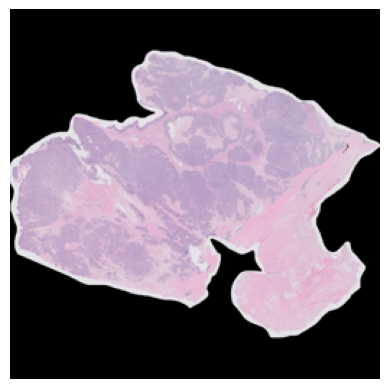

In [92]:
idx=1
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(X[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [97]:
from torch import nn
import torchinfo
from torch import nn
import torch

Dropout=0.4
HIDDEN_DIM=64
K=2


class Res2DModel(nn.Module):
    def __init__(self, name="Res2DModel", K=1):
        super().__init__()
        self.name = name
        self.K = K

        self.convStackK2 = nn.Sequential(nn.BatchNorm2d(3),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(3, K*2, (3,3), padding=(1,1))
                                        )
        self.convStackK2_1 = nn.Sequential(nn.BatchNorm2d(K*2),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*2, K*2, (3,3), padding=(1,1)))
        self.convStackK2_2 = nn.Sequential(nn.BatchNorm2d(K*2),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*2, K*4, (3,3), stride=(2,2), padding=(1,1)))

        self.convStackK4 = nn.Sequential(nn.BatchNorm2d(K*4),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*4, K*4, (3,3), padding=(1,1)))
        self.convStackK4_1 = nn.Sequential(nn.BatchNorm2d(K*4),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*4, K*4, (3,3), padding=(1,1)))
        self.convStackK4_2 = nn.Sequential(nn.BatchNorm2d(K*4),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*4, K*8, (3,3), stride=(2,2), padding=(1,1)))

        self.convStackK8 = nn.Sequential(nn.BatchNorm2d(K*8),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*8, K*8, (3,3), padding=(1,1)))
        self.convStackK8_1 = nn.Sequential(nn.BatchNorm2d(K*8),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*8, K*8, (3,3), padding=(1,1)))
        self.convStackK8_2 = nn.Sequential(nn.BatchNorm2d(K*8),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*8, K*16, (3,3), stride=(2,2), padding=(1,1)))

        self.convStackK16 = nn.Sequential(nn.BatchNorm2d(K*16),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*16, K*16, (3,3), padding=(1,1)))
        self.convStackK16_1 = nn.Sequential(nn.BatchNorm2d(K*16),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*16, K*16, (3,3), padding=(1,1)))
        self.convStackK16_2 = nn.Sequential(nn.BatchNorm2d(K*16),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*16, K*32, (3,3), stride=(2,2), padding=(1,1)))
        
        self.convStackK32 = nn.Sequential(nn.BatchNorm2d(K*32),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*32, K*32, (3,3), padding=(1,1)))
        self.convStackK32_1 = nn.Sequential(nn.BatchNorm2d(K*32),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*32, K*32, (3,3), padding=(1,1)))
        self.convStackK32_2 = nn.Sequential(nn.BatchNorm2d(K*32),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*32, K*32, (3,3), stride=(2,2), padding=(1,1)))
        self.convStackK32_3 = nn.Sequential(nn.BatchNorm2d(K*32),
                                        nn.LeakyReLU(),
                                        nn.Conv2d(K*32, K*32, (3,3), padding=(1,1)))

        self.gap = nn.AdaptiveAvgPool3d((1,1,1))
        
        #nn.Linear(K*16*8*8*depth, HIDDEN_DIM)
        self.linearStack1 = nn.Sequential(nn.Linear(K*32*8*8, HIDDEN_DIM),
                                          nn.LeakyReLU(),
                                          nn.Dropout(Dropout))

        self.classifier = nn.Sequential(nn.Linear(HIDDEN_DIM,HIDDEN_DIM),
                                        nn.LeakyReLU(),
                                        nn.Dropout(Dropout),
                                        nn.Linear(HIDDEN_DIM,len(enc.classes_)),
                                        nn.Softmax(dim=1))
    def forward(self, x):
        x2 = self.convStackK2(x)
        x2_2 = self.convStackK2_1(x2)
        concat2 = torch.add(x2,x2_2)
        x2Out = self.convStackK2_2(concat2)

        x4 = self.convStackK4(x2Out)
        x4 = self.convStackK4_1(x4)
        concat4 = torch.add(x4,x2Out)
        x4Out = self.convStackK4_2(concat4)

        x8 = self.convStackK8(x4Out)
        x8 = self.convStackK8_1(x8)
        concat8 = torch.add(x8,x4Out)
        x8Out = self.convStackK8_2(concat8)

        x16 = self.convStackK16(x8Out)
        x16 = self.convStackK16_1(x16)
        concat16 = torch.add(x16,x8Out)
        x16Out = self.convStackK16_2(concat16)

        x32 = self.convStackK32(x16Out)
        x32 = self.convStackK32_1(x32)
        concat32 = torch.add(x32,x16Out)
        x32 = self.convStackK32_2(concat32)
        x32Out = self.convStackK32_3(x32)
      
        # x = self.gap(x32Out)
         
        x = torch.flatten(x32Out, start_dim=1)
        x = self.linearStack1(x)
        out = self.classifier(x)

        return out
    
model = Res2DModel("Res2DModel_K_{}".format(K), K=K)

# print(model)

# testbatch = next(iter(trainLoader))
# testX = testbatch[0]
# yhat = model(testX)
# input_names = ['3DArray']
# output_names = ['yBowel', 'yExtra', 'yKidney', 'yLiver', 'ySpleen']
# torch.onnx.export(model, testX, 'convModel.onnx', input_names=input_names, output_names=output_names, export_params=True, )


from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                   Output Shape              Param #
Res2DModel                               [8, 5]                    --
├─Sequential: 1-1                        [8, 4, 256, 256]          --
│    └─BatchNorm2d: 2-1                  [8, 3, 256, 256]          6
│    └─LeakyReLU: 2-2                    [8, 3, 256, 256]          --
│    └─Conv2d: 2-3                       [8, 4, 256, 256]          112
├─Sequential: 1-2                        [8, 4, 256, 256]          --
│    └─BatchNorm2d: 2-4                  [8, 4, 256, 256]          8
│    └─LeakyReLU: 2-5                    [8, 4, 256, 256]          --
│    └─Conv2d: 2-6                       [8, 4, 256, 256]          148
├─Sequential: 1-3                        [8, 8, 128, 128]          --
│    └─BatchNorm2d: 2-7                  [8, 4, 256, 256]          8
│    └─LeakyReLU: 2-8                    [8, 4, 256, 256]          --
│    └─Conv2d: 2-9                       [8, 8, 128, 128]          296
├─Sequential: 1

In [80]:
# model_graph.visual_graph

In [98]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter


LOG_INTERVAL=2
epochs = 100
EARLY_STOPPING_PATIENCE=10
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
lossFn = torch.nn.BCELoss()


# accMetric = tf.keras.metrics.BinaryAccuracy()
accMetric = metrics.BinaryAccuracy().to(device)
ceMetric = metrics.BinaryNormalizedEntropy().to(device)
aurocMetric = metrics.BinaryAUROC().to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

# CEMetricVal = tf.keras.metrics.BinaryCrossentropy()
# accMetricVal = tf.keras.metrics.BinaryAccuracy()
# f1MetricVal = tf.keras.metrics.F1Score(threshold=0.5, average="micro")
accMetricVal = metrics.BinaryAccuracy().to(device)




def train(dataloader, model, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        # predictions = torch.cat(pred, axis=-1)
        
        loss = lossFn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        accMetric.update(torch.flatten(pred), torch.flatten(y))
        aurocMetric.update(torch.flatten(pred), torch.flatten(y))
        ceMetric.update(torch.flatten(pred), torch.flatten(y))
        
        if batch % LOG_INTERVAL == 0:
            loss = loss.item()
            print("loss: {:>5f}, acc: {:.4f}, CrossEntropy: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss, accMetric.compute(), ceMetric.compute().item(), aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloader, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        lossAdd = lossFn(pred, y)
        loss += lossAdd.detach().cpu().numpy()
        accMetricVal.update(torch.flatten(pred), torch.flatten(y))
        
    lossVal = loss.item()/(batch+1)
    print("Weighted Avg Cross Entropy: {:>7f}".format(lossVal))
    print("Accuracy: {:>7f}".format(accMetricVal.compute()))
    summary_writer.add_scalar("Val BCE", lossVal, epoch)
    summary_writer.add_scalar("Val Accuracy", accMetricVal.compute(), epoch)
    summary_writer.flush()
    return lossVal


maxStep=len(trainIds)//BATCH_SIZE
bestValCE=99.0
bestEpoch=0


for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    ceMetric.reset()
    aurocMetric.reset()
    avgCEVal = validate(valLoader, model, t)
    accMetricVal.reset()
    if saveModel:
        model_scripted = torch.jit.script(model) # Export to TorchScript
        fileName = "{}_epoch{}_CE{:.4f}.pt".format(model.name, t, avgCEVal)
        model_scripted.save(os.path.join(DATA_PATH, fileName))
    
    #Early stopping
    if avgCEVal < bestValCE:
        bestValCE = avgCEVal
        bestEpoch = t
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break
print("Done!")

Epoch 1
-------------------------------
loss: 0.503621, acc: 0.8000, CrossEntropy: 1.0064, AUROC: 0.4727  [    0/  376]
loss: 0.497010, acc: 0.8000, CrossEntropy: 1.0014, AUROC: 0.4909  [   16/  376]
loss: 0.492116, acc: 0.8000, CrossEntropy: 0.9979, AUROC: 0.5120  [   32/  376]
loss: 0.488406, acc: 0.8000, CrossEntropy: 0.9956, AUROC: 0.5410  [   48/  376]
loss: 0.494400, acc: 0.8000, CrossEntropy: 0.9933, AUROC: 0.5575  [   64/  376]
loss: 0.497233, acc: 0.8000, CrossEntropy: 0.9916, AUROC: 0.5673  [   80/  376]
loss: 0.502419, acc: 0.8000, CrossEntropy: 0.9942, AUROC: 0.5519  [   96/  376]
loss: 0.472466, acc: 0.8000, CrossEntropy: 0.9926, AUROC: 0.5629  [  112/  376]
loss: 0.507680, acc: 0.8000, CrossEntropy: 0.9945, AUROC: 0.5562  [  128/  376]
loss: 0.485209, acc: 0.8000, CrossEntropy: 0.9920, AUROC: 0.5680  [  144/  376]
loss: 0.456107, acc: 0.8000, CrossEntropy: 0.9847, AUROC: 0.6032  [  160/  376]
loss: 0.471232, acc: 0.8000, CrossEntropy: 0.9828, AUROC: 0.6137  [  176/  376]


In [20]:
# torch.save(model.state_dict, os.path.join(DATA_PATH, "convModel.pt"))

# model_scripted = torch.jit.script(model) # Export to TorchScript
# model_scripted.save('model_scripted.pt') # Save